
# SKAX 이탈 예측 모델링

| # | 섹션 | 포인트 |
|---|------|--------|
| 1 | 데이터 준비 | features.csv 로드, 불필요 컬럼 제거, 타깃 분리 |
| 2 | 인코딩 | 범주형 LabelEncoder, 결측치 처리 |
| 3 | Train/Test Split | 8:2, stratify |
| 4 | Logistic Regression | 기준점 베이스라인 |
| 5 | Random Forest | 트리 앙상블 |
| 6 | XGBoost | Gradient Boosting |
| 7 | LightGBM | Gradient Boosting (경량) |
| 8 | 모델 비교 | Accuracy / F1 / AUC-ROC |
| 9 | 피처 중요도 | 이탈에 영향 주는 변수 확인 |
| 10 | 임계값 튜닝 | Precision-Recall 트레이드오프 |
| 11 | 단계별 비교 | 생깡통 -> 베이스라인 -> 결측치처리 -> 영화데이터 |

## 0. 라이브러리

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

SEED = 42

---
## 1. 데이터 준비

features.csv 로드 후 불필요 컬럼 제거, 타깃 분리.

In [25]:
df = pd.read_csv('features.csv', encoding='utf-8-sig')
print(f'원본 shape: {df.shape}')
df.head(3)

원본 shape: (17968, 51)


,user_no,product_cd,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,...,genre_판타지,days_to_first_watch,cold_start,recency_days,dur_w1,dur_w2,dur_w3,retention_w2,retention_w3,watch_per_day
0,3dbaf64f285bad12318d0fc90287f109b0300b2651bfb0...,pk_2025,151,1.0,0,0,0,android,1,0,...,0.000000,0.0,1,6.0,44.0,170.0,96.0,1,1,0.161290
1,8153a206cc14eb12ce2a70b726a4ac6702593d623e9452...,pk_1487,190,1.0,1,0,0,mobile,1,0,...,0.000000,12.0,0,8.0,0.0,81.0,0.0,1,0,0.064516
2,aee89dd1c5f97e68e379d9ffcff1e5e68aaa5e874b3a75...,pk_1487,190,1.0,0,0,1,mobile,1,1,...,0.363636,2.0,1,1.0,196.0,387.0,183.0,1,1,0.516129


=== 이탈 분포 ===
is_churn
0    11876
1     6092
Name: count, dtype: int64
이탈률: 33.9%


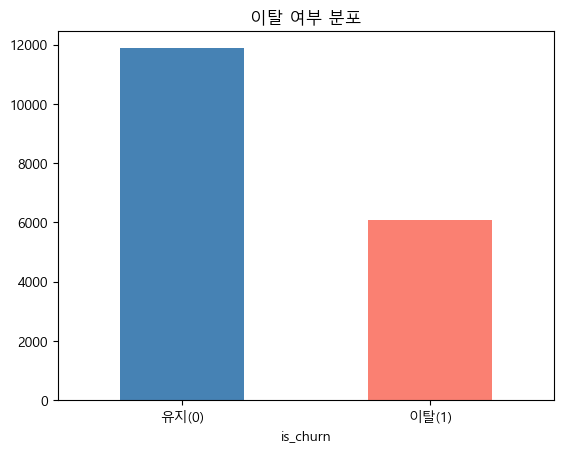

In [26]:
# 타깃 분포 확인
print('=== 이탈 분포 ===')
print(df['is_churn'].value_counts())
print(f'이탈률: {df["is_churn"].mean():.1%}')

df['is_churn'].value_counts().plot(
    kind='bar', color=['steelblue','salmon'], title='이탈 여부 분포'
)
plt.xticks([0,1], ['유지(0)','이탈(1)'], rotation=0)
plt.show()

In [27]:
# 불필요 컬럼 제거
# - ID 컬럼: 식별자, 모델에 무의미
# - 날짜 컬럼: reg_date/end_date -> sub_days로 이미 수치화됨
# - age_group: age로 이미 수치화됨
# - genre_*_x, genre_*_y: genre_* (합산본)으로 대체됨
DROP_COLS = ['user_no', 'uid', 'USER_ID', 'reg_date', 'end_date', 'age_group','amount']

# repurchase만 리케이지 제거
# (is_churn_prevented는 조치를 취한 것일 뿐 실제 이탈 여부를 알려주지 않으므로 유효 피처로 유지)
LEAKAGE_COLS = ['repurchase']

GENRE_X_Y = [c for c in df.columns if c.startswith('genre_') and
             (c.endswith('_x') or c.endswith('_y'))]

df_model = df.drop(columns=DROP_COLS + LEAKAGE_COLS + GENRE_X_Y, errors='ignore')
print(f'ID/날짜 제거  ({len(DROP_COLS)}개): {DROP_COLS}')
print(f'리케이지 제거 ({len(LEAKAGE_COLS)}개): {LEAKAGE_COLS}')
print(f'중복장르 제거 ({len(GENRE_X_Y)}개): genre_*_x / genre_*_y')
print(f'\n잔여 shape: {df_model.shape}')

miss = df_model.isnull().sum()
print('\n결측치 현황:')
print(miss[miss > 0].sort_values(ascending=False))

ID/날짜 제거  (7개): ['user_no', 'uid', 'USER_ID', 'reg_date', 'end_date', 'age_group', 'amount']
리케이지 제거 (1개): ['repurchase']
중복장르 제거 (0개): genre_*_x / genre_*_y

잔여 shape: (17968, 45)

결측치 현황:
Series([], dtype: int64)


---
## 2. 인코딩

범주형 변수를 숫자로 변환. `is_churn_prevented`, `promotion_yn` 등은
이미 08.가나에서 0/1 처리됨 → 여기서는 나머지 문자열 컬럼만 처리.

In [28]:
# 범주형 컬럼 확인
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('문자열 컬럼:', cat_cols)

for c in cat_cols:
    print(f'  {c}: {df_model[c].unique()[:8]}')

문자열 컬럼: ['product_cd', 'payment_device']
  product_cd: ['pk_2025' 'pk_1487' 'pk_2027' 'pk_1489' 'pk_1488' 'pk_1508' 'pk_2029'
 'pk_1506']
  payment_device: ['android' 'mobile' 'pc' 'lgtv' 'ios' 'sstv' 'ott' 'smarttv']


In [29]:
# 범주형 컬럼 확인
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('문자열 컬럼:', cat_cols)

for c in cat_cols:
    print(f'  {c}: {df_model[c].unique()[:8]}')

# LabelEncoder 적용 (features.csv에서 아직 인코딩 안 된 컬럼)
le_dict = {}
for c in cat_cols:
    df_model[c] = df_model[c].fillna('unknown')
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c].astype(str))
    le_dict[c] = le

# is_usd bool -> int
df_model['is_usd'] = df_model['is_usd'].map(
    {True:1, False:0, 'True':1, 'False':0, 1:1, 0:0}
)

# 시청 없는 유저 수치 피처 결측 -> 0 (한 번도 안 본 유저)
view_cols = [
    'watch_count','unique_movies','active_days','total_duration',
    'avg_duration','avg_completion','avg_rewatch_ratio','rewatch_count',
    'days_to_first_watch','cold_start','watch_per_day',
    'recency_days','dur_w1','dur_w2','dur_w3','retention_w2','retention_w3'
]
view_cols = [c for c in view_cols if c in df_model.columns]
df_model[view_cols] = df_model[view_cols].fillna(0)

print('인코딩 완료 shape:', df_model.shape)
print('잔여 결측치:', df_model.isnull().sum().sum())
df_model.dtypes.value_counts()

문자열 컬럼: ['product_cd', 'payment_device']
  product_cd: ['pk_2025' 'pk_1487' 'pk_2027' 'pk_1489' 'pk_1488' 'pk_1508' 'pk_2029'
 'pk_1506']
  payment_device: ['android' 'mobile' 'pc' 'lgtv' 'ios' 'sstv' 'ott' 'smarttv']
인코딩 완료 shape: (17968, 45)
잔여 결측치: 0


float64    31
int64      12
int32       2
Name: count, dtype: int64

---
## 3. Train / Test Split (8:2)

불균형 데이터이므로 `stratify=y` 로 이탈 비율 유지.

In [30]:
X = df_model.drop(columns=['is_churn'])
y = df_model['is_churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train 이탈률: {y_train.mean():.1%}  |  Test 이탈률: {y_test.mean():.1%}')
print(f'\n피처 수: {X.shape[1]}개')
print(f'scale_pos_weight (불균형 보정): {(y_train==0).sum()/(y_train==1).sum():.2f}')

Train: (14374, 44)  |  Test: (3594, 44)
Train 이탈률: 33.9%  |  Test 이탈률: 33.9%

피처 수: 44개
scale_pos_weight (불균형 보정): 1.95


In [31]:
# Logistic Regression 용 스케일링 (트리는 불필요, LR은 필요)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('스케일링 완료')

스케일링 완료


---
## 4~7. 모델 학습

공통 평가 헬퍼 함수 정의.

In [32]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        '모델':       name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'F1':         round(f1_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred), 4),
        'Recall':     round(recall_score(y_true, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC':     round(average_precision_score(y_true, y_prob), 4),
    }

all_results = []
all_probs   = {}  # ROC/PR 곡선용

### 4. Logistic Regression (베이스라인)

선형 결정 경계 기준점. 이후 트리 기반 모델과 성능 비교용.

In [33]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # 불균형 보정
    random_state=SEED
)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['유지','이탈']))

res = evaluate('Logistic Regression', y_test, lr_pred, lr_prob)
print(f'ROC-AUC: {res["ROC-AUC"]}  |  PR-AUC: {res["PR-AUC"]}')
all_results.append(res)
all_probs['Logistic Regression'] = lr_prob

=== Logistic Regression ===
              precision    recall  f1-score   support

          유지       0.75      0.64      0.69      2375
          이탈       0.45      0.58      0.51      1219

    accuracy                           0.62      3594
   macro avg       0.60      0.61      0.60      3594
weighted avg       0.65      0.62      0.63      3594

ROC-AUC: 0.6559  |  PR-AUC: 0.5464


### 5. Random Forest

In [34]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['유지','이탈']))

res = evaluate('Random Forest', y_test, rf_pred, rf_prob)
print(f'ROC-AUC: {res["ROC-AUC"]}  |  PR-AUC: {res["PR-AUC"]}')
all_results.append(res)
all_probs['Random Forest'] = rf_prob

=== Random Forest ===
              precision    recall  f1-score   support

          유지       0.70      0.94      0.80      2375
          이탈       0.66      0.23      0.34      1219

    accuracy                           0.70      3594
   macro avg       0.68      0.58      0.57      3594
weighted avg       0.69      0.70      0.65      3594

ROC-AUC: 0.6678  |  PR-AUC: 0.5489


### 6. XGBoost

In [35]:
spw = neg / pos  # scale_pos_weight

xgbm = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, scale_pos_weight=spw,
    tree_method='hist', random_state=SEED,
    n_jobs=-1, verbosity=0,
    early_stopping_rounds=50, eval_metric='logloss'
)
xgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgbm.predict(X_test)
xgb_prob = xgbm.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, xgb_pred, target_names=['유지','이탈']))

res = evaluate('XGBoost', y_test, xgb_pred, xgb_prob)
print(f'ROC-AUC: {res["ROC-AUC"]}  |  PR-AUC: {res["PR-AUC"]}')
all_results.append(res)
all_probs['XGBoost'] = xgb_prob

=== XGBoost ===
              precision    recall  f1-score   support

          유지       0.75      0.75      0.75      2375
          이탈       0.51      0.51      0.51      1219

    accuracy                           0.66      3594
   macro avg       0.63      0.63      0.63      3594
weighted avg       0.66      0.66      0.66      3594

ROC-AUC: 0.6766  |  PR-AUC: 0.5695


### 7. LightGBM

In [36]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, max_depth=-1,
    scale_pos_weight=spw,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgb_pred = lgbm.predict(X_test)
lgb_prob = lgbm.predict_proba(X_test)[:, 1]

print('=== LightGBM ===')
print(classification_report(y_test, lgb_pred, target_names=['유지','이탈']))

res = evaluate('LightGBM', y_test, lgb_pred, lgb_prob)
print(f'ROC-AUC: {res["ROC-AUC"]}  |  PR-AUC: {res["PR-AUC"]}')
all_results.append(res)
all_probs['LightGBM'] = lgb_prob

=== LightGBM ===
              precision    recall  f1-score   support

          유지       0.73      0.89      0.80      2375
          이탈       0.61      0.35      0.45      1219

    accuracy                           0.70      3594
   macro avg       0.67      0.62      0.62      3594
weighted avg       0.69      0.70      0.68      3594

ROC-AUC: 0.6925  |  PR-AUC: 0.5878


---
## 8. 모델 성능 비교

Accuracy / F1 / ROC-AUC 기준 4개 모델 비교.

> **이탈 예측은 불균형 데이터** → Accuracy 보다 ROC-AUC / F1 이 핵심 지표.

In [37]:
summary = pd.DataFrame(all_results).set_index('모델')
print(summary.to_string())
summary

                     Accuracy      F1  Precision  Recall  ROC-AUC  PR-AUC
모델                                                                       
Logistic Regression    0.6196  0.5102     0.4529  0.5841   0.6559  0.5464
Random Forest          0.6989  0.3402     0.6627  0.2289   0.6678  0.5489
XGBoost                0.6647  0.5063     0.5057  0.5070   0.6766  0.5695
LightGBM               0.7042  0.4466     0.6111  0.3519   0.6925  0.5878


,Accuracy,F1,Precision,Recall,ROC-AUC,PR-AUC
모델,,,,,,
Logistic Regression,0.6196,0.5102,0.4529,0.5841,0.6559,0.5464
Random Forest,0.6989,0.3402,0.6627,0.2289,0.6678,0.5489
XGBoost,0.6647,0.5063,0.5057,0.5070,0.6766,0.5695
LightGBM,0.7042,0.4466,0.6111,0.3519,0.6925,0.5878


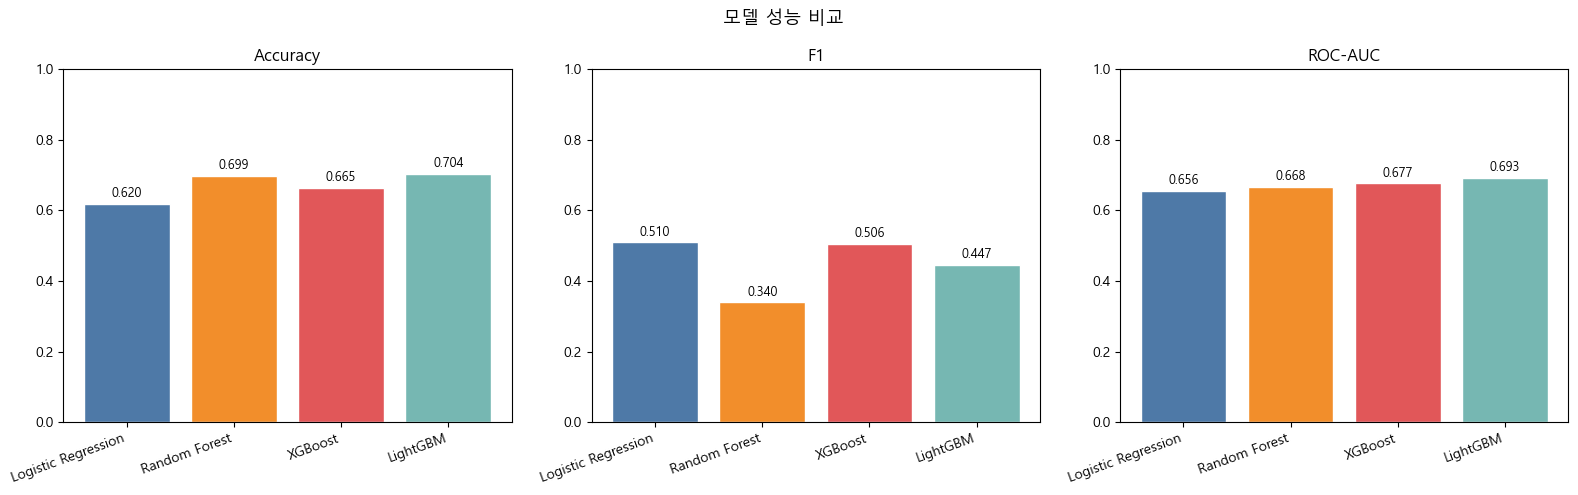

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('모델 성능 비교', fontsize=13)

metrics = ['Accuracy', 'F1', 'ROC-AUC']
colors  = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for ax, m in zip(axes, metrics):
    vals = summary[m]
    bars = ax.bar(vals.index, vals, color=colors, edgecolor='white')
    ax.set_title(m)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(vals.index, rotation=20, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

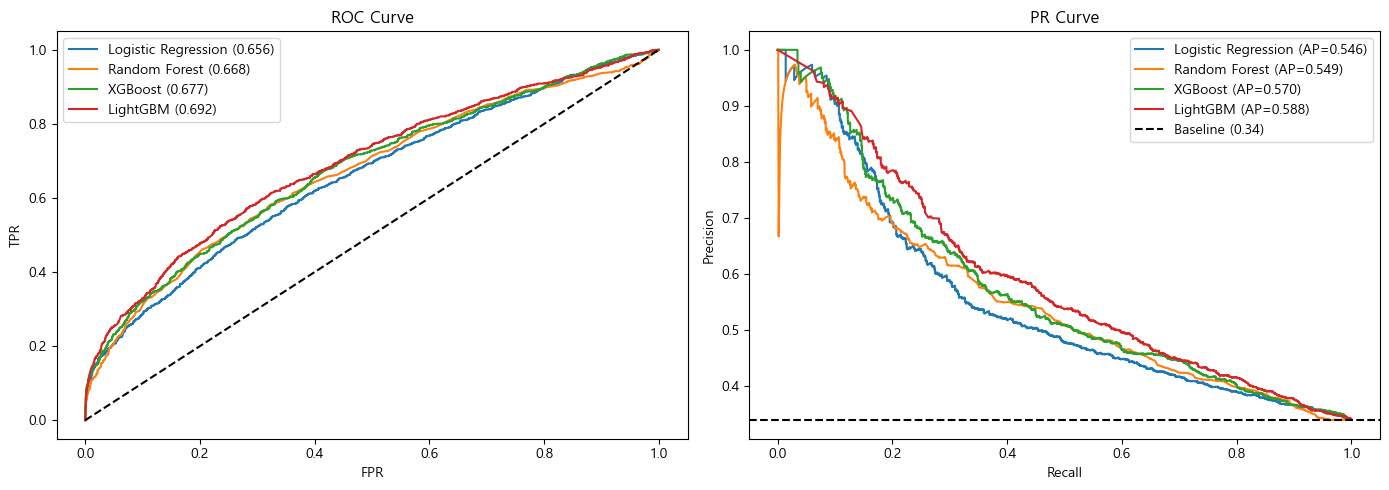

In [39]:
# ROC / PR 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend()

ax = axes[1]
for name, prob in all_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), linestyle='--', color='k',
           label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curve'); ax.legend()

plt.tight_layout()
plt.show()

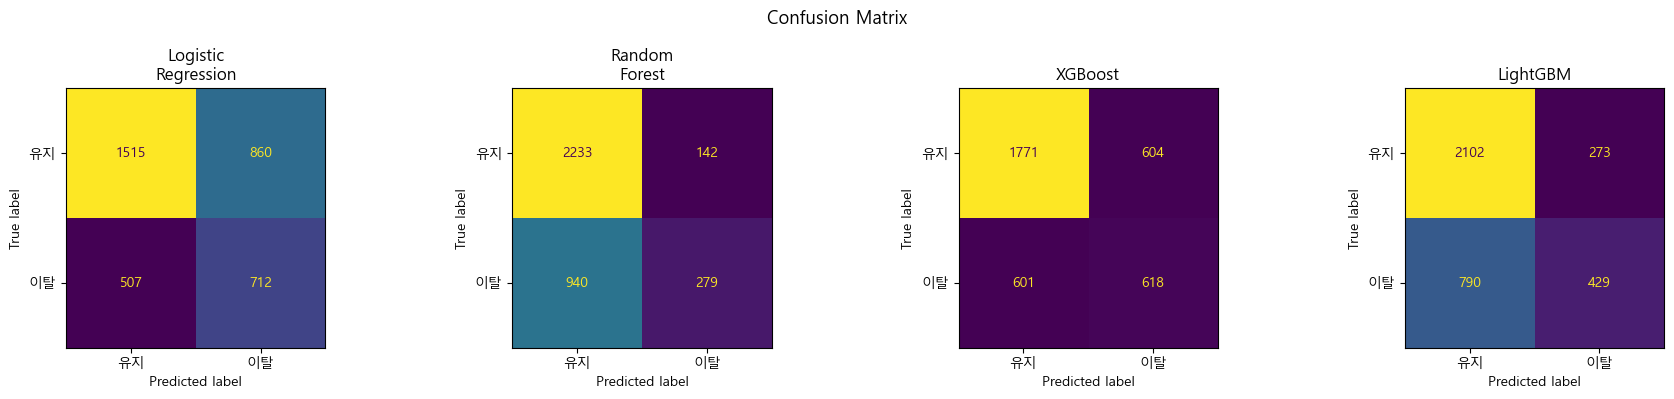

In [40]:
# Confusion Matrix (4개 모델)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix', fontsize=13)

model_preds = [
    ('Logistic\nRegression', lr_pred),
    ('Random\nForest',       rf_pred),
    ('XGBoost',              xgb_pred),
    ('LightGBM',             lgb_pred),
]
for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['유지','이탈']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

---
## 9. 피처 중요도

LightGBM 기준 + Random Forest 비교.

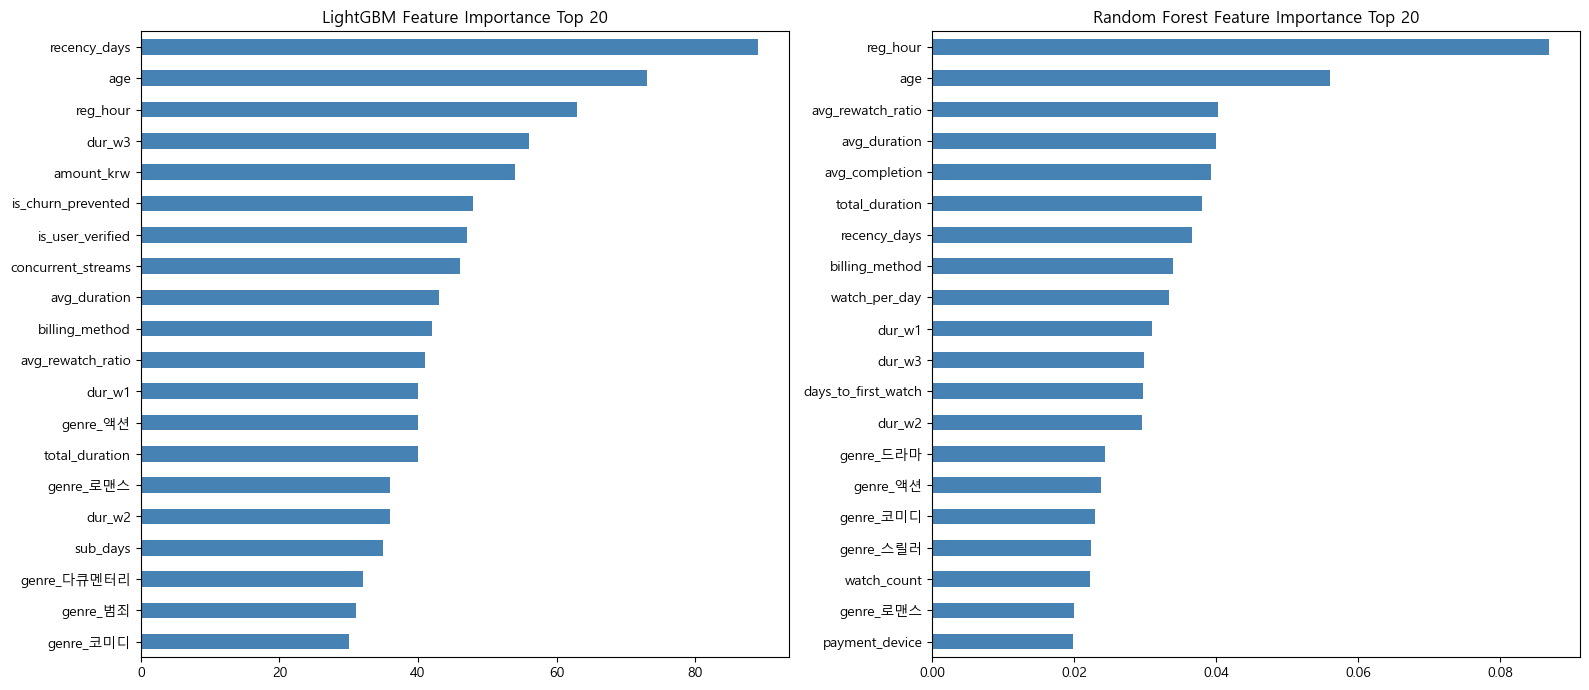

=== LightGBM Top 15 ===
recency_days          89
age                   73
reg_hour              63
dur_w3                56
amount_krw            54
is_churn_prevented    48
is_user_verified      47
concurrent_streams    46
avg_duration          43
billing_method        42
avg_rewatch_ratio     41
dur_w1                40
genre_액션              40
total_duration        40
genre_로맨스             36


In [41]:
fi_lgb = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_rf  = pd.Series(rf.feature_importances_,   index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, fi) in zip(axes, [('LightGBM', fi_lgb), ('Random Forest', fi_rf)]):
    fi.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} Feature Importance Top 20')
plt.tight_layout()
plt.show()

print('=== LightGBM Top 15 ===')
print(fi_lgb.head(15).to_string())

---
## 10. 임계값 튜닝 (LightGBM)

기본 임계값 0.5 대신 최적 임계값을 찾아 Precision/Recall 균형 조정.

- **이탈 예측 목적이 '놓치지 않기'** 라면 → Recall 높이는 방향 (임계값 낮춤)
- **마케팅 비용 절감 목적** 이라면 → Precision 높이는 방향 (임계값 높임)

In [42]:
thresholds = np.arange(0.1, 0.91, 0.05)

rows = []
for t in thresholds:
    pred_t = (lgb_prob >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'Precision': round(precision_score(y_test, pred_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred_t, zero_division=0),    4),
        'F1':        round(f1_score(y_test, pred_t, zero_division=0),        4),
        'Accuracy':  round(accuracy_score(y_test, pred_t),                   4),
    })

thresh_df = pd.DataFrame(rows).set_index('threshold')
print(thresh_df.to_string())

best_f1_t   = thresh_df['F1'].idxmax()
best_rec_t  = thresh_df[thresh_df['Recall'] >= 0.7]['Precision'].idxmax()
print(f'\nF1 최대 임계값: {best_f1_t}')
print(f'Recall>=0.7 중 Precision 최대 임계값: {best_rec_t}')

           Precision  Recall      F1  Accuracy
threshold                                     
0.10          0.3392  1.0000  0.5065    0.3392
0.15          0.3392  1.0000  0.5065    0.3392
0.20          0.3392  1.0000  0.5065    0.3392
0.25          0.3403  1.0000  0.5078    0.3425
0.30          0.3506  0.9623  0.5139    0.3826
0.35          0.3790  0.8843  0.5306    0.4694
0.40          0.4407  0.7285  0.5492    0.5943
0.45          0.5180  0.5422  0.5299    0.6736
0.50          0.6111  0.3519  0.4466    0.7042
0.55          0.7993  0.1797  0.2934    0.7065
0.60          0.8402  0.1509  0.2559    0.7023
0.65          0.9137  0.1042  0.1870    0.6928
0.70          0.9423  0.0804  0.1481    0.6864
0.75          0.9620  0.0623  0.1171    0.6811
0.80          0.0000  0.0000  0.0000    0.6608
0.85          0.0000  0.0000  0.0000    0.6608
0.90          0.0000  0.0000  0.0000    0.6608

F1 최대 임계값: 0.4
Recall>=0.7 중 Precision 최대 임계값: 0.4


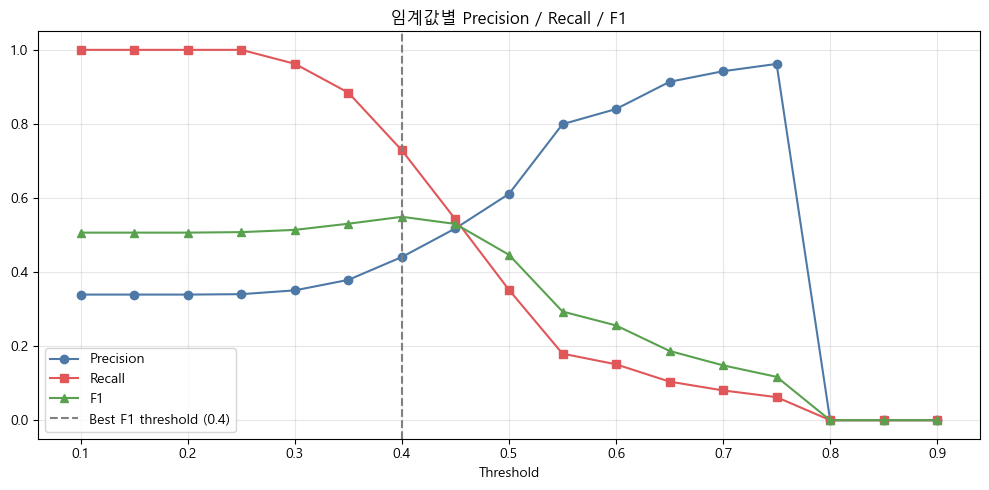

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresh_df.index, thresh_df['Precision'], 'o-', label='Precision', color='#4e79a7')
ax.plot(thresh_df.index, thresh_df['Recall'],    's-', label='Recall',    color='#e15759')
ax.plot(thresh_df.index, thresh_df['F1'],        '^-', label='F1',        color='#59a14f')
ax.axvline(best_f1_t, linestyle='--', color='gray', label=f'Best F1 threshold ({best_f1_t})')
ax.set_xlabel('Threshold')
ax.set_title('임계값별 Precision / Recall / F1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# 최적 임계값 적용 결과
best_pred = (lgb_prob >= best_f1_t).astype(int)
print(f'=== LightGBM (threshold={best_f1_t}) ===')
print(classification_report(y_test, best_pred, target_names=['유지','이탈']))

print('--- 기본 (0.5) vs 최적 임계값 비교 ---')
before = evaluate('LightGBM (0.5)',         y_test, lgb_pred,  lgb_prob)
after  = evaluate(f'LightGBM ({best_f1_t})', y_test, best_pred, lgb_prob)
pd.DataFrame([before, after]).set_index('모델')

=== LightGBM (threshold=0.4) ===
              precision    recall  f1-score   support

          유지       0.79      0.53      0.63      2375
          이탈       0.44      0.73      0.55      1219

    accuracy                           0.59      3594
   macro avg       0.62      0.63      0.59      3594
weighted avg       0.67      0.59      0.60      3594

--- 기본 (0.5) vs 최적 임계값 비교 ---


,Accuracy,F1,Precision,Recall,ROC-AUC,PR-AUC
모델,,,,,,
LightGBM (0.5),0.7042,0.4466,0.6111,0.3519,0.6925,0.5878
LightGBM (0.4),0.5943,0.5492,0.4407,0.7285,0.6925,0.5878


---
## 11. 단계별 피처 비교 (LightGBM)

피처를 단계적으로 추가했을 때 AUC 변화를 확인.

| 단계 | 추가 피처 |
|------|-----------|
| 생깡통 | 멤버십 기본 12개 (리케이지 제외) |
| 베이스라인 | + 기본 시청 9개 |
| 결측치 처리 후 | + 완주율/유지율/최근성 8개 |
| 영화 데이터 포함 | + 장르 선호도 14개 |

In [45]:
MEMBERSHIP_COLS = [
    'product_cd', 'billing_method', 'amount_krw', 'concurrent_streams',
    'promotion_yn', 'is_churn_prevented',
    'payment_device', 'is_user_verified',
    'age', 'reg_hour', 'sub_days', 'is_usd',
    # repurchase 제외 (리케이지 — 재구매=1이면 is_churn=0 확정)
] + [c for c in df_model.columns if c.startswith('gender_')]

BASE_VIEW_COLS = [
    'watch_count','unique_movies','active_days','total_duration',
    'avg_duration','avg_completion','days_to_first_watch','cold_start','watch_per_day',
]
EXTRA_VIEW_COLS = [
    'avg_rewatch_ratio','rewatch_count','recency_days',
    'dur_w1','dur_w2','dur_w3','retention_w2','retention_w3',
]
GENRE_COLS = [c for c in df_model.columns
              if c.startswith('genre_') and not c.endswith(('_x','_y'))]

stage_features = [
    ('1. 생깡통',         MEMBERSHIP_COLS),
    ('2. 베이스라인',     MEMBERSHIP_COLS + BASE_VIEW_COLS),
    ('3. 결측치처리후',   MEMBERSHIP_COLS + BASE_VIEW_COLS + EXTRA_VIEW_COLS),
    ('4. 영화데이터포함', MEMBERSHIP_COLS + BASE_VIEW_COLS + EXTRA_VIEW_COLS + GENRE_COLS),
]

stage_results = []
for name, feat_list in stage_features:
    feat_list = [f for f in feat_list if f in df_model.columns]
    Xs = df_model[feat_list]
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=SEED)
    neg2, pos2 = (ytr==0).sum(), (ytr==1).sum()
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=neg2/pos2, random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(Xtr, ytr, eval_set=[(Xte,yte)],
          callbacks=[lgb.early_stopping(50,verbose=False)])
    prob_s = m.predict_proba(Xte)[:,1]
    pred_s = m.predict(Xte)
    r = evaluate(name, yte, pred_s, prob_s)
    r['피처수'] = len(feat_list)
    stage_results.append(r)
    print(f'{name} ({len(feat_list)}개)  ROC-AUC={r["ROC-AUC"]}  F1={r["F1"]}')

stage_df = pd.DataFrame(stage_results).set_index('모델')
stage_df

1. 생깡통 (12개)  ROC-AUC=0.6935  F1=0.4469
2. 베이스라인 (21개)  ROC-AUC=0.6928  F1=0.4161
3. 결측치처리후 (29개)  ROC-AUC=0.6914  F1=0.4301
4. 영화데이터포함 (43개)  ROC-AUC=0.6924  F1=0.4315


,Accuracy,F1,Precision,Recall,ROC-AUC,PR-AUC,피처수
모델,,,,,,,
1. 생깡통,0.7059,0.4469,0.6171,0.3503,0.6935,0.5816,12
2. 베이스라인,0.7048,0.4161,0.6321,0.3101,0.6928,0.5793,21
3. 결측치처리후,0.7051,0.4301,0.6240,0.3281,0.6914,0.5826,29
4. 영화데이터포함,0.7067,0.4315,0.6299,0.3281,0.6924,0.5846,43


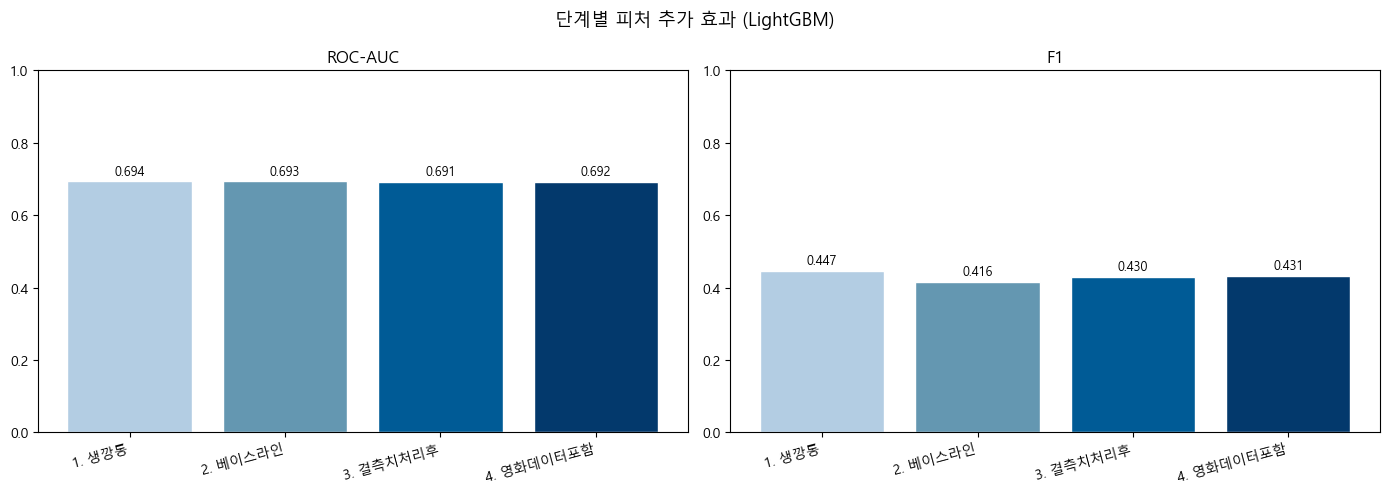

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('단계별 피처 추가 효과 (LightGBM)', fontsize=13)

for ax, m in zip(axes, ['ROC-AUC', 'F1']):
    vals = stage_df[m]
    bars = ax.bar(range(len(vals)), vals, color=['#b3cde3','#6497b1','#005b96','#03396c'],
                 edgecolor='white')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=15, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(m)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()